In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

df = pd.read_csv("../data/gme_merged_analysis.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

#Re-engineer features (strictly lagging features by 1 day)
df['Price_Change'] = df['Close'].diff()
df['Price_Direction'] = (df['Price_Change'] > 0).astype(int)

df['Yesterday_Posts'] = df['total_posts'].shift(1)
df['Yesterday_Sentiment'] = df['mean_sentiment'].shift(1)
df['Yesterday_Stock_Volume'] = df['Volume'].shift(1)
df['Yesterday_Price_Return'] = df['Close'].shift(1) - df['Close'].shift(2)
df['Reddit_3Day_Hype_Avg'] = df['total_posts'].shift(1).rolling(window=3).mean()

df_ml = df.dropna().copy()

feature_cols = ['Yesterday_Posts', 'Yesterday_Sentiment', 'Yesterday_Stock_Volume', 'Yesterday_Price_Return', 'Reddit_3Day_Hype_Avg']
X = df_ml[feature_cols]
y = df_ml['Price_Direction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)
print(f"Data set up completed. Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Data set up completed. Training samples: 20, Testing samples: 6


In [2]:
model = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_split=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

import os
os.makedirs("../models", exist_ok=True)
model_path = "../models/gme_random_forest_model.joblib"
joblib.dump(model, model_path)
print(f"Success! Trained machine learning model exported and saved to: {model_path}")

Success! Trained machine learning model exported and saved to: ../models/gme_random_forest_model.joblib


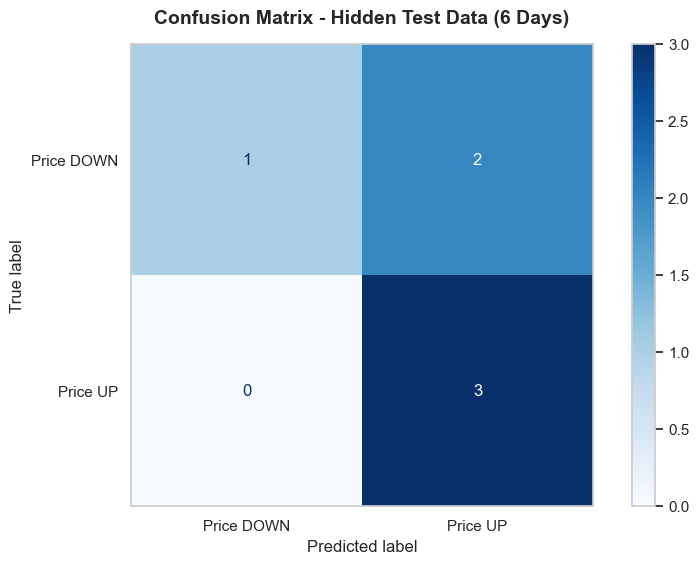

In [3]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Price DOWN', 'Price UP'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Hidden Test Data (6 Days)", fontsize=14, fontweight='bold', pad=15)
plt.grid(False)
plt.show()

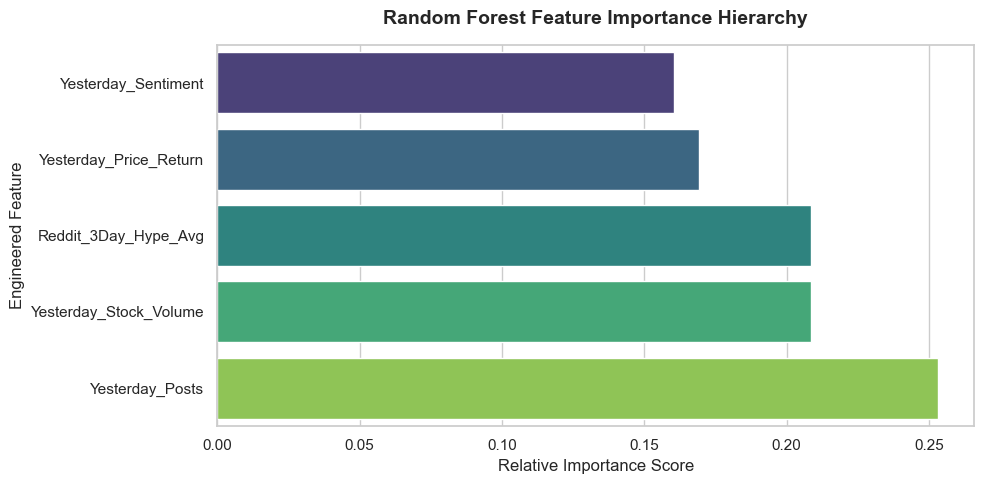

In [4]:
#Organizing feature importances
importances = model.feature_importances_
feat_importance_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_importance_df = feat_importance_df.sort_values(by='Importance', ascending=True) # Ascending for visual horizontal bar rendering

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title("Random Forest Feature Importance Hierarchy", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Engineered Feature", fontsize=12)
plt.tight_layout()
plt.show()